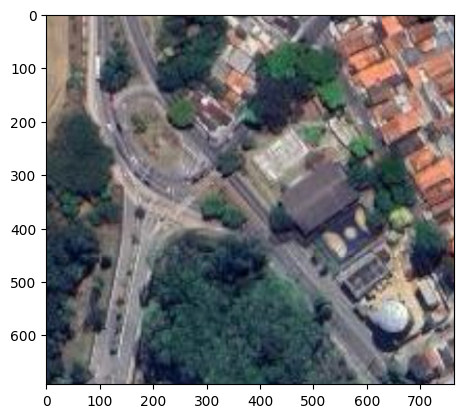

In [1]:
# A simple example that uses a perceptron to classify
# image data
#
# Author: Fabrício Galende Marques de Carvalho

from random import shuffle
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np

# load image from file
data_path = "data/"
file_name = "main_entrance_of_inpe_rgb.bmp"
img = mpimg.imread(data_path + file_name)

# display the image
plt.imshow(img)


[ 55 126  86 255]


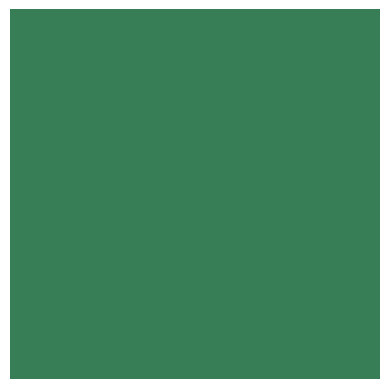

[236 146 104 255]


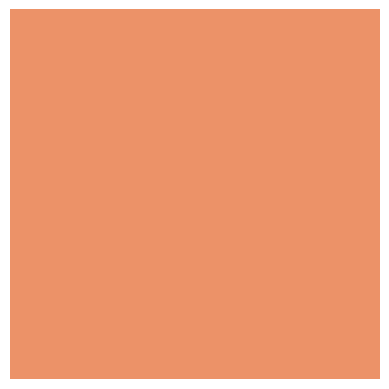

In [2]:
# Take image samples to perform neural network training:

# First, let`s examine a positive and a negative example:
# positive
x = 148
y = 541
print(img[x,y])
pixel = np.array([[img[x,y]]], dtype=np.uint8)  

plt.imshow(pixel)
plt.axis('off')
plt.show()

#negative
x = 109
y = 619
print(img[x,y])
pixel = np.array([[img[x,y]]], dtype=np.uint8)  

plt.imshow(pixel)
plt.axis('off')
plt.show()

In [3]:
# get sample coordinates:
positive_examples_coords = [(267, 70), (586, 271), (148,541)]
negative_examples_coords = [ (109, 619), (558, 685), (19, 502)]
p_n_examples = positive_examples_coords + negative_examples_coords
points = []
classes = []
for i, v in enumerate( p_n_examples ):
    points.append(img[v[0],v[1]][0:3])
    if i < len(p_n_examples)/2:
        classes.append([1])
    else:
        classes.append([0])
        

print(points)
print(classes)

[array([33, 50, 58], dtype=uint8), array([35, 66, 71], dtype=uint8), array([ 55, 126,  86], dtype=uint8), array([236, 146, 104], dtype=uint8), array([198, 191, 168], dtype=uint8), array([ 97,  92, 106], dtype=uint8)]
[[1], [1], [1], [0], [0], [0]]


In [4]:
# Build a new input considering bias:
new_input = []
bias = 1
for x_in in points:
    new_input.append(np.concatenate((x_in, np.array([int(bias)]))))
print(new_input)

[array([33, 50, 58,  1]), array([35, 66, 71,  1]), array([ 55, 126,  86,   1]), array([236, 146, 104,   1]), array([198, 191, 168,   1]), array([ 97,  92, 106,   1])]


In [5]:
# now we import, configure and initialized our perceptron
from perceptron import *

# configure the activation function:
def my_activation_function(v):
    return (1/(1+np.exp(-v)))

# freeze random number generator seed to get the same result
np.random.seed(42)  
# build a perceptron instance that uses this activation function.
my_act_function = ActivationFunction(my_activation_function)
my_perceptron = Perceptron(my_act_function, 4, 1)                      
print(my_perceptron.synaptic_weights)

[[0.37454012 0.95071431 0.73199394 0.59865848]]


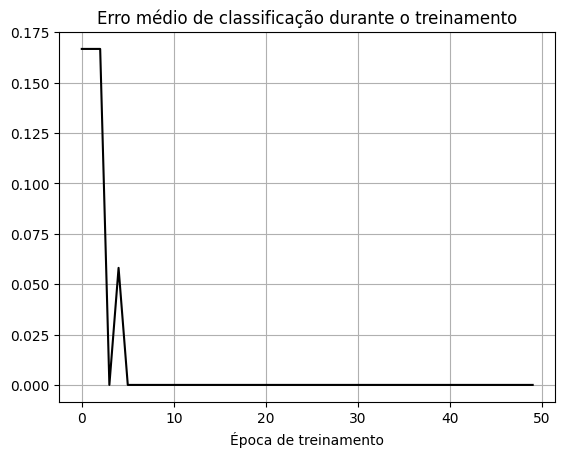

In [7]:
# Now we train our perceptron

learning_rate = 0.01
n_epochs = 50
e_epoch = [] #to store the classification error in each epoch (average)
w_0_epoch = []
indices = list(range(len(classes)))
e_instantaneous = []
for epoch in range(n_epochs): # for each epoch
    e_point = []
    shuffle(indices)
    for k in indices:    #for each input/output pair
        y_e = my_perceptron.output(new_input[k])
        e_point.append(classes[k][0] - y_e[0])
        e_instantaneous.append(classes[k][0] - y_e[0])
        my_perceptron.learn(classes[k], y_e, new_input[k], learning_rate)
    e_epoch.append( np.mean(e_point) )
    w_0_epoch.append(my_perceptron.synaptic_weights[0][0])

plt.plot(e_epoch, color="black")
plt.title("Erro médio de classificação durante o treinamento")
plt.xlabel("Época de treinamento")
plt.grid()

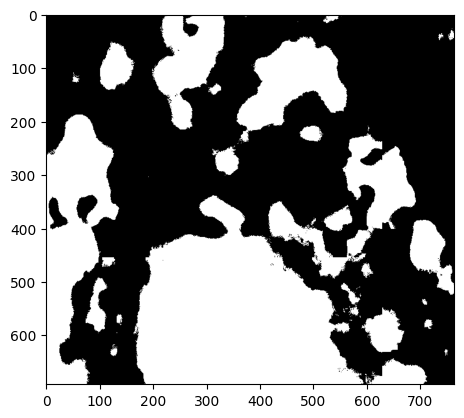

In [12]:
# Now we try to classify image regions:

n_rows = len(img)
n_cols = len(img[0])
classified_img = np.zeros((n_rows, n_cols, 3), dtype=np.uint8)  # n_rows x n_cols RGB
for x in range(n_rows):
    for y in range(n_cols):
        nn_input =  np.concatenate( ( img[x,y][0:3], np.array([int(bias)])))
        y_e = my_perceptron.output(nn_input)
        if y_e[0]  > 0.85:
            classified_img[x,y] = [255, 255, 255]
        else:
            classified_img[x,y] = [0, 0, 0]

plt.imshow(classified_img)
        
